In [1]:
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from mlp_lora_module import MLPWithLoRATrainingAuto
from utils_lora import plot_decision_boundary
from pathlib import Path
import shutil
import torch
from concrete.ml.torch.hybrid_model import HybridFHEModel

torch.manual_seed(0)
torch.use_deterministic_algorithms(True)


N_SAMPLES = 1000

def prepare_data(X, y, test_size=0.3, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)
    return X_train, X_test, y_train, y_test

# Generate synthetic 2D data
X1, y1 = make_moons(n_samples=N_SAMPLES, noise=0.2, random_state=42)
X2, y2 = make_circles(n_samples=N_SAMPLES, noise=0.2, factor=0.5, random_state=42)

# Prepare data
X1_train, X1_test, y1_train, y1_test = prepare_data(X1, y1)
X2_train, X2_test, y2_train, y2_test = prepare_data(X2, y2)

In [2]:
# Initialize the model
input_size = 2
hidden_size = 128
output_size = 2

model = MLPWithLoRATrainingAuto(input_size, hidden_size, output_size, lora_rank=4, use_lora=False)

Epoch [10/100], Loss: 0.3104
Epoch [20/100], Loss: 0.2514
Epoch [30/100], Loss: 0.2075
Epoch [40/100], Loss: 0.1640
Epoch [50/100], Loss: 0.1314
Epoch [60/100], Loss: 0.1082
Epoch [70/100], Loss: 0.0941
Epoch [80/100], Loss: 0.0850
Epoch [90/100], Loss: 0.0788
Epoch [100/100], Loss: 0.0740
Accuracy on the first task: 97.00%


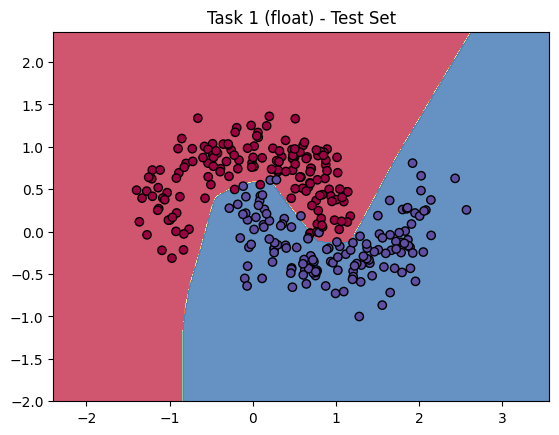

In [3]:
# Training loop for the first task with visualization
num_epochs = 100
model.train()
for epoch in range(num_epochs):
    model.optimizer.zero_grad()
    outputs = model.inference(X1_train)
    loss = model.criterion(outputs, y1_train)
    loss.backward()
    model.optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
        
model.eval()
with torch.no_grad():
    outputs = model.inference(X1_test)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y1_test).sum().item() / y1_test.size(0)
    print(f'Accuracy on the first task: {accuracy*100:.2f}%')
    plot_decision_boundary(model, X1_test.numpy(), y1_test.numpy(), 'Task 1 (float) - Test Set', use_inference=True)

In [4]:
model.toggle_lora(enable=True)

hybrid_model = HybridFHEModel(model, ["fc1", "fc2.forward_module", "fc2.backward_module"], serialize_deai=False)

In [5]:
inputset_sample = 100

# Include both dataset to avoid bound issues with quantization
x_train_mixed = torch.cat((X1_train[:inputset_sample], X2_train[:inputset_sample]), dim=0)
y_train_mixed = torch.cat((y1_train[:inputset_sample], y2_train[:inputset_sample]), dim=0)

inputset = (x_train_mixed, y_train_mixed)

hybrid_model.model.toggle_calibrate(enable=True)

hybrid_model.compile_model(inputset, n_bits=2, only_build=False)

hybrid_model.model.toggle_calibrate(enable=False)

Accuracy on the second task: 87.33%


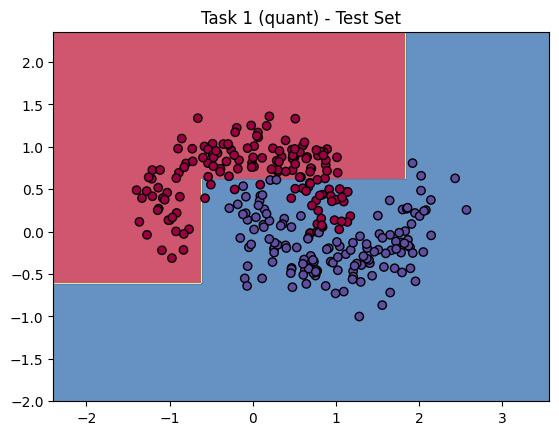

In [6]:
hybrid_model.model.toggle_lora(enable=False)
hybrid_model.set_fhe_mode("disable")

hybrid_model.model.eval()
with torch.no_grad():
    outputs = hybrid_model.model.inference(X1_test)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y1_test).sum().item() / y1_test.size(0)
    print(f'Accuracy on the second task: {accuracy*100:.2f}%')
    plot_decision_boundary(hybrid_model.model, X1_test.numpy(), y2_test.numpy(), 'Task 1 (quant) - Test Set', use_inference=True)

In [8]:
hybrid_model.model.toggle_lora(enable=True)

DEAI_SAMPLES = 10

X2_train_deai = X1_train[:DEAI_SAMPLES]
y2_train_deai = y1_train[:DEAI_SAMPLES]

num_epochs = 1
for epoch in range(num_epochs):
    loss = hybrid_model((X2_train_deai, y2_train_deai), fhe="deai")

    # if (epoch+1) % 10 == 0:
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
       

Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product
Wrong dot product


KeyboardInterrupt: 

In [ ]:
# 10 samples, 1 epoch

# Disable:
# Epoch [1/1], Loss: 0.3702

# Simulate
# Epoch [1/1], Loss: 0.3702

# DeAI:
# Epoch [1/1], Loss: 0.7907

: 

In [ ]:
# Disable (700 samples):
# Epoch [10/100], Loss: 0.8162
# Epoch [20/100], Loss: 0.4678
# Epoch [30/100], Loss: 0.3359
# Epoch [40/100], Loss: 0.2949
# Epoch [50/100], Loss: 0.2727
# Epoch [60/100], Loss: 0.2615
# Epoch [70/100], Loss: 0.2519
# Epoch [80/100], Loss: 0.2447
# Epoch [90/100], Loss: 0.2385
# Epoch [100/100], Loss: 0.2335

# DeAI (1 sample, 1 epoch: 18s):


: 

In [ ]:
hybrid_model.model.toggle_lora(True)

hybrid_model.set_fhe_mode("disable")
hybrid_model.model.eval()

with torch.no_grad():
    outputs = hybrid_model.model.inference(X2_test)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y2_test).sum().item() / y2_test.size(0)
    print(f'Accuracy on the second task: {accuracy*100:.2f}%')
    plot_decision_boundary(hybrid_model.model, X2_test.numpy(), y2_test.numpy(), 'Task 2 (quant) - Test Set', use_inference=True)

: 

In [ ]:
hybrid_model.model.toggle_lora(False)

hybrid_model.model.eval()
with torch.no_grad():
    outputs = hybrid_model.model.inference(X1_test)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y1_test).sum().item() / y1_test.size(0)
    print(f'Accuracy on the second task: {accuracy*100:.2f}%')
    plot_decision_boundary(hybrid_model.model, X1_test.numpy(), y2_test.numpy(), 'Task 1 (quant) - Test Set', use_inference=True)

: 

In [ ]:
total_weights = 0
for name, param in hybrid_model.model.named_parameters():
    total_weights += param.numel()
    print(name, param.numel())

print(f"Total number of weights: {total_weights}")

: 

In [ ]:
hybrid_model.model

: 

In [ ]:
path = Path("lora_mlp")

if (path.is_dir() and any(path.iterdir())):
        shutil.rmtree(path)

hybrid_model.save_and_clear_private_info(path)

: 

In [ ]:
total_weights = 0
for name, param in hybrid_model.model.named_parameters():
    total_weights += param.numel()
    print(name, param.numel())

print(f"Total number of weights: {total_weights}")

: 